# Knowledge Graph XAI System for CFRP Composites

This notebook demonstrates the Knowledge Graph-based Explainable AI system for RUL prediction in CFRP composite materials.

## Contents:
1. Load trained models
2. Build and visualize Knowledge Graph
3. Generate explanations for predictions
4. Compare model explanations
5. Interactive exploration

In [15]:
# Import required libraries
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Import custom modules
from modules import CFRPKnowledgeGraph, XAIExplainer


Using device: cpu


## 1. Build Knowledge Graph

Create the domain knowledge graph for CFRP composite degradation.

In [16]:
# Build Knowledge Graph
kg = CFRPKnowledgeGraph()

# Print graph statistics
print("Knowledge Graph Statistics:")
print(f"  Nodes: {kg.graph.number_of_nodes()}")
print(f"  Edges: {kg.graph.number_of_edges()}")
print("\nNode Types:")
for node_type in ['feature', 'phenomenon', 'stage']:
    nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
    print(f"  {node_type.capitalize()}s: {len(nodes)}")
    for node in nodes:
        print(f"    - {node}")

Knowledge Graph Statistics:
  Nodes: 33
  Edges: 25

Node Types:
  Features: 24
    - avg_delta_psd
    - std_delta_psd
    - avg_delta_tof
    - std_delta_tof
    - avg_scatter_energy
    - std_scatter_energy
    - avg_rms
    - avg_peak_frequency
    - n_pzt_paths
    - mean_intensity
    - std_intensity
    - image_entropy
    - mean_strain_rms
    - std_strain_rms
    - mean_strain_amplitude
    - n_active_channels
    - stiffness_degradation
    - cycles
    - normalized_cycles
    - delta_mean_intensity
    - delta_stiffness
    - delta_avg_delta_psd
    - RUL
    - normalized_RUL
  Phenomenons: 5
    - crack_propagation
    - delamination
    - matrix_cracking
    - fiber_breakage
    - stiffness_loss
  Stages: 4
    - healthy
    - early_damage
    - progressive
    - critical


## 2. Visualize Knowledge Graph

Visualize the structure of the knowledge graph.

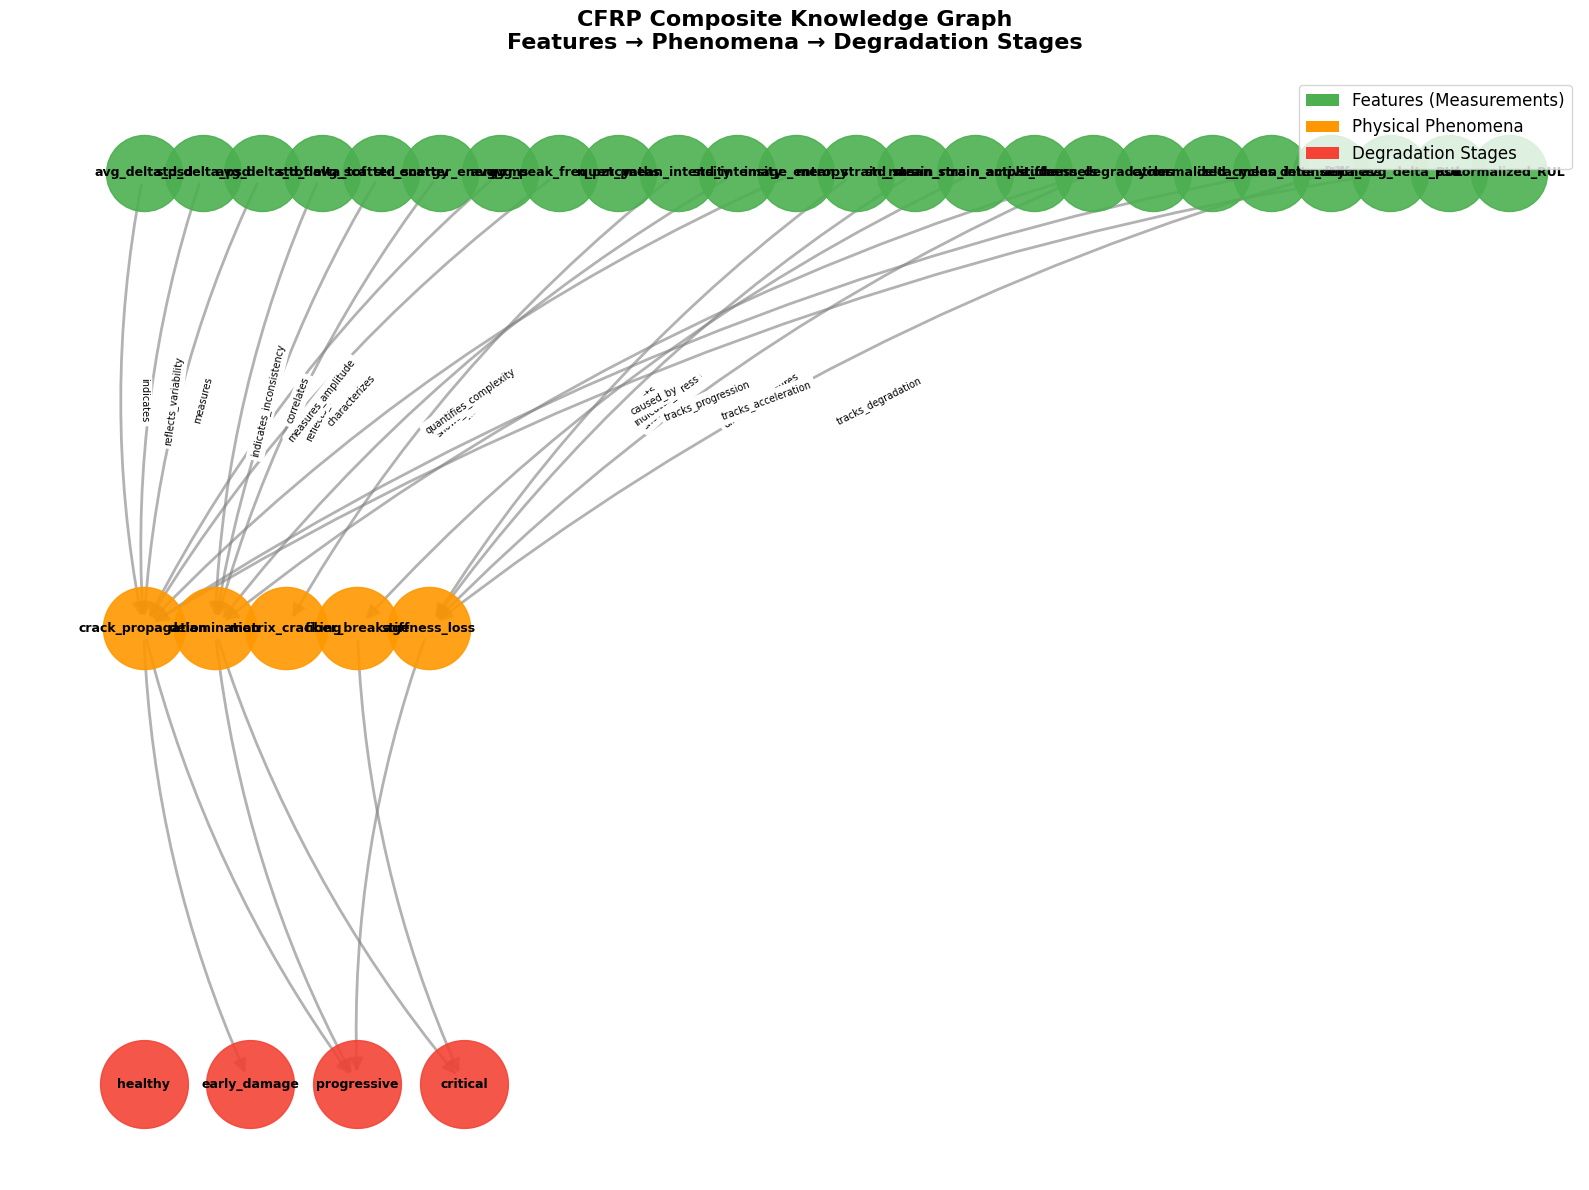

In [17]:
# Visualize Knowledge Graph
fig, ax = plt.subplots(figsize=(16, 12))

# Create hierarchical layout
pos = {}
feature_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'feature']
phenomenon_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'phenomenon']
stage_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'stage']

# Position nodes in layers
y_levels = {'feature': 0, 'phenomenon': -3, 'stage': -6}
for i, node in enumerate(feature_nodes):
    pos[node] = (i * 2.5, y_levels['feature'])
for i, node in enumerate(phenomenon_nodes):
    pos[node] = (i * 3, y_levels['phenomenon'])
for i, node in enumerate(stage_nodes):
    pos[node] = (i * 4.5, y_levels['stage'])

# Draw nodes by type
node_colors = {'feature': '#4CAF50', 'phenomenon': '#FF9800', 'stage': '#F44336'}
node_sizes = {'feature': 3000, 'phenomenon': 3500, 'stage': 4000}

for node_type in ['feature', 'phenomenon', 'stage']:
    nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
    nx.draw_networkx_nodes(kg.graph, pos, nodelist=nodes,
                          node_color=node_colors[node_type],
                          node_size=node_sizes[node_type],
                          alpha=0.9, ax=ax)

# Draw edges with arrows
nx.draw_networkx_edges(kg.graph, pos, edge_color='gray',
                      arrows=True, arrowsize=20, width=2,
                      alpha=0.6, ax=ax, connectionstyle='arc3,rad=0.1')

# Draw labels
nx.draw_networkx_labels(kg.graph, pos, font_size=9, font_weight='bold', ax=ax)

# Add edge labels (relation types)
edge_labels = nx.get_edge_attributes(kg.graph, 'relation')
nx.draw_networkx_edge_labels(kg.graph, pos, edge_labels, font_size=7, ax=ax)

# Title and legend
ax.set_title('CFRP Composite Knowledge Graph\nFeatures → Phenomena → Degradation Stages',
            fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=node_colors['feature'], label='Features (Measurements)'),
    Patch(facecolor=node_colors['phenomenon'], label='Physical Phenomena'),
    Patch(facecolor=node_colors['stage'], label='Degradation Stages')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Load Trained Models and Data

Load the trained models and test data for explanation generation.

In [26]:
# Load models and data
# NOTE: Update these paths based on your saved model locations
import pickle
from sklearn.preprocessing import MinMaxScaler

# Load scalers
with open('../outputs/saved_models/feature_scaler.pkl', 'rb') as f:
    feature_scaler = pickle.load(f)
with open('../outputs/saved_models/target_scaler.pkl', 'rb') as f:
    target_scaler = pickle.load(f)

# Load test data
with open('../outputs/saved_models/test_data.pkl', 'rb') as f:
    test_data = pickle.load(f)
    X_test = test_data['X_test']
    y_test = test_data['y_test']  # ⚠️ These are NORMALIZED values (0-1 range)

print(f"Test data loaded: {X_test.shape[0]} samples")
print(f"Sequence length: {X_test.shape[1]}")
print(f"Features: {X_test.shape[2]}")

# ⚠️ Display target scaler info
print(f"\n{'='*80}")
print(f"TARGET SCALER INFORMATION:")
print(f"{'='*80}")
print(f"Original RUL Range: {target_scaler.data_min_[0]:.0f} to {target_scaler.data_max_[0]:.0f} cycles")
print(f"Normalized Range: 0.0 to 1.0")
print(f"\nExample conversions:")
print(f"  Normalized 0.00 → Actual {target_scaler.inverse_transform([[0.0]])[0, 0]:.0f} cycles")
print(f"  Normalized 0.50 → Actual {target_scaler.inverse_transform([[0.5]])[0, 0]:.0f} cycles")
print(f"  Normalized 1.00 → Actual {target_scaler.inverse_transform([[1.0]])[0, 0]:.0f} cycles")
print(f"{'='*80}\n")

# ⚠️ IMPORTANT: Use only the 20 features that models were trained with
# The models have input_dim=20, so we need exactly 20 feature names
feature_names = [
    # PZT sensor features (9)
    'avg_delta_psd', 'std_delta_psd', 'avg_delta_tof', 'std_delta_tof',
    'avg_scatter_energy', 'std_scatter_energy', 'avg_rms', 'avg_peak_frequency',
    # 'n_pzt_paths',
    # X-ray features (3)
    # 'mean_intensity', 'std_intensity', 'image_entropy',
    # Strain gauge features (4)
    'mean_strain_rms', 'std_strain_rms', 'mean_strain_amplitude', 'n_active_channels',
    # Mechanical features (1)
    'stiffness_degradation',
    # Temporal/derived features (3) - adjusted to match 20 total
    'cycles', 'normalized_cycles', 'RUL'
]

print(f"\n✅ Using {len(feature_names)} features (matching model input_dim={X_test.shape[2]}):")
for i, fname in enumerate(feature_names, 1):
    print(f"   {i:2d}. {fname}")

# Verify feature count matches
if len(feature_names) != X_test.shape[2]:
    print(f"\n⚠️  WARNING: Feature mismatch!")
    print(f"   Feature names: {len(feature_names)}")
    print(f"   Model expects: {X_test.shape[2]}")
else:
    print(f"\n✅ Feature count verified: {len(feature_names)} features match model input")

Test data loaded: 30 samples
Sequence length: 10
Features: 16

TARGET SCALER INFORMATION:
Original RUL Range: 0 to 223963 cycles
Normalized Range: 0.0 to 1.0

Example conversions:
  Normalized 0.00 → Actual 0 cycles
  Normalized 0.50 → Actual 111982 cycles
  Normalized 1.00 → Actual 223963 cycles


✅ Using 16 features (matching model input_dim=16):
    1. avg_delta_psd
    2. std_delta_psd
    3. avg_delta_tof
    4. std_delta_tof
    5. avg_scatter_energy
    6. std_scatter_energy
    7. avg_rms
    8. avg_peak_frequency
    9. mean_strain_rms
   10. std_strain_rms
   11. mean_strain_amplitude
   12. n_active_channels
   13. stiffness_degradation
   14. cycles
   15. normalized_cycles
   16. RUL

✅ Feature count verified: 16 features match model input


In [27]:
# Load trained models
from modules.model_architecture import TransformerRULPredictor, LSTMRULPredictor
from modules.drl_models import DDPGActor

# Model hyperparameters (must match training configuration)
input_dim = 16  # Current training uses 20 features
d_model = 128
nhead = 8
num_layers = 3
hidden_dim = 128

# Load Transformer model
transformer_model = TransformerRULPredictor(
    input_dim=input_dim,
    d_model=d_model,
    nhead=nhead,
    # num_layers=num_layers
).to(device)
transformer_model.load_state_dict(torch.load('../outputs/saved_models/transformer_model.pth', map_location=device))
transformer_model.eval()
print("✓ Transformer model loaded")

# Load LSTM model
lstm_model = LSTMRULPredictor(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers
).to(device)
lstm_model.load_state_dict(torch.load('../outputs/saved_models/lstm_model.pth', map_location=device))
lstm_model.eval()
print("✓ LSTM model loaded")

# Load DDPG Actor model
ddpg_model = DDPGActor(input_dim=input_dim, hidden_dim=hidden_dim).to(device)
ddpg_model.load_state_dict(torch.load('../outputs/saved_models/ddpg_actor.pth', map_location=device))
ddpg_model.eval()
print("✓ DDPG Actor model loaded")

print(f"\n✅ All models loaded successfully on {device}")

✓ Transformer model loaded
✓ LSTM model loaded
✓ DDPG Actor model loaded

✅ All models loaded successfully on cpu


In [28]:
# Diagnostic: Check model predictions across multiple samples
print(f"\n{'='*80}")
print(f"DIAGNOSTIC: Checking Model Predictions Across Samples")
print(f"{'='*80}\n")

# Test on a few samples
test_samples = [0, 10, 25, 50, 100]
print(f"{'Sample':<10} {'Actual (cycles)':<20} {'Trans. Pred':<15} {'LSTM Pred':<15} {'DDPG Pred':<15}")
print(f"{'-'*80}")

for idx in test_samples:
    if idx >= len(X_test):
        continue
    
    sample = X_test[idx:idx+1]
    actual_norm = float(y_test[idx])
    actual_cycles = target_scaler.inverse_transform([[actual_norm]])[0, 0]
    
    # Get predictions
    with torch.no_grad():
        trans_norm = transformer_model(torch.FloatTensor(sample).to(device)).cpu().item()
        lstm_norm = lstm_model(torch.FloatTensor(sample).to(device)).cpu().item()
        ddpg_norm = ddpg_model(torch.FloatTensor(sample).to(device)).cpu().item()
    
    trans_cycles = target_scaler.inverse_transform([[trans_norm]])[0, 0]
    lstm_cycles = target_scaler.inverse_transform([[lstm_norm]])[0, 0]
    ddpg_cycles = target_scaler.inverse_transform([[ddpg_norm]])[0, 0]
    
    print(f"{idx:<10} {actual_cycles:<20.0f} {trans_cycles:<15.0f} {lstm_cycles:<15.0f} {ddpg_cycles:<15.0f}")

print(f"\n{'='*80}")
print(f"⚠️  If predictions look flat or unreasonable:")
print(f"   1. Models may not be trained properly")
print(f"   2. Models may be outputting constant values (sigmoid saturation)")
print(f"   3. Training data may have issues")
print(f"{'='*80}\n")


DIAGNOSTIC: Checking Model Predictions Across Samples

Sample     Actual (cycles)      Trans. Pred     LSTM Pred       DDPG Pred      
--------------------------------------------------------------------------------
0          44793                172407          156812          58             
10         29347                172551          145048          259            
25         6178                 172557          151737          68             

⚠️  If predictions look flat or unreasonable:
   1. Models may not be trained properly
   2. Models may be outputting constant values (sigmoid saturation)
   3. Training data may have issues



## 4. Initialize XAI Explainers

Create explainer instances for all models using the knowledge graph.

In [29]:
# Create explainers for all models
transformer_explainer = XAIExplainer(kg, device)
lstm_explainer = XAIExplainer(kg, device)
ddpg_explainer = XAIExplainer(kg, device)
print("✓ XAI Explainers initialized (Transformer, LSTM, DDPG)")

✓ XAI Explainers initialized (Transformer, LSTM, DDPG)


## 5. Generate Explanation for Sample

Generate detailed explanation for a test sample using the Transformer model.

In [30]:
# Generate explanation
sample_idx = 25
sample_sequence = X_test[sample_idx:sample_idx+1]
actual_rul_normalized = float(y_test[sample_idx])
actual_rul = target_scaler.inverse_transform([[actual_rul_normalized]])[0, 0]

print(f"Sample shape: {sample_sequence.shape}")
print(f"Analyzing sample at cycle: {sample_sequence[0, -1, feature_names.index('cycles')]}")

# ⚠️ CRITICAL: Pass target_scaler to explainer for inverse transformation!
transformer_exp = transformer_explainer.explain_prediction(
    model=transformer_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='transformer',
    top_k=10,  # Show top 10 features instead of just 5
    target_scaler=target_scaler  # Required for de-normalization!
)

# Add actual RUL to explanation
transformer_exp['actual_rul'] = actual_rul

print(f"\n{'='*80}")
print(f"TRANSFORMER EXPLANATION FOR SAMPLE {sample_idx}")
print(f"{'='*80}")

print(f"\n📊 Predicted RUL: {transformer_exp['predicted_rul']:.0f} cycles")
print(f"    (normalized: {transformer_exp['predicted_rul_normalized']:.4f})")
print(f"🎯 Actual RUL: {transformer_exp['actual_rul']:.0f} cycles")
print(f"    (normalized: {actual_rul_normalized:.4f})")
print(f"📉 Error: {abs(transformer_exp['predicted_rul'] - transformer_exp['actual_rul']):.0f} cycles")
print(f"    ({abs(transformer_exp['predicted_rul'] - transformer_exp['actual_rul'])/transformer_exp['actual_rul']*100:.1f}% error)")

print(f"\n🔍 TOP {len(transformer_exp['feature_importances'])} FEATURE CONTRIBUTIONS:")
for i, (feature, importance) in enumerate(transformer_exp['feature_importances'], 1):
    print(f"   {i:2d}. {feature:30s}: {importance:+.6f} ({importance*100:.2f}%)")

print(f"\n🧠 KNOWLEDGE GRAPH REASONING PATHS:")
print(f"   Found {len(transformer_exp['paths'])} explanation paths")
for i, path in enumerate(transformer_exp['paths'][:5], 1):  # Show top 5 paths
    print(f"\n   Path {i} (strength: {path['strength']:.3f}):")
    path_str = " → ".join([f"{node['type']}: {node['name']}" for node in path['nodes']])
    print(f"      {path_str}")

print(f"\n{'='*80}")

Sample shape: (1, 10, 16)
Analyzing sample at cycle: -12.070456504821777

TRANSFORMER EXPLANATION FOR SAMPLE 25

📊 Predicted RUL: 172557 cycles
    (normalized: 0.7705)
🎯 Actual RUL: 6178 cycles
    (normalized: 0.0276)
📉 Error: 166379 cycles
    (2693.0% error)

🔍 TOP 10 FEATURE CONTRIBUTIONS:
    1. n_active_channels             : +0.133995 (13.40%)
    2. avg_rms                       : +0.128682 (12.87%)
    3. normalized_cycles             : +0.116031 (11.60%)
    4. avg_peak_frequency            : +0.097578 (9.76%)
    5. mean_strain_amplitude         : +0.081424 (8.14%)
    6. RUL                           : +0.078410 (7.84%)
    7. stiffness_degradation         : +0.074927 (7.49%)
    8. std_delta_tof                 : +0.056485 (5.65%)
    9. mean_strain_rms               : +0.042943 (4.29%)
   10. std_scatter_energy            : +0.039300 (3.93%)

🧠 KNOWLEDGE GRAPH REASONING PATHS:
   Found 10 explanation paths

   Path 1 (strength: 0.103):
      feature: avg_rms → phenomenon

## 6. Compare Explanations Across Models

Compare explanations from Transformer, LSTM, and DDPG models for the same sample.

In [31]:
# Compare explanations from all models
lstm_exp = lstm_explainer.explain_prediction(
    model=lstm_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='lstm',
    top_k=10,
    target_scaler=target_scaler  # Required!
)
lstm_exp['actual_rul'] = actual_rul

ddpg_exp = ddpg_explainer.explain_prediction(
    model=ddpg_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='ddpg',
    top_k=10,
    target_scaler=target_scaler  # Required!
)
ddpg_exp['actual_rul'] = actual_rul

print(f"\n{'='*80}")
print(f"CROSS-MODEL COMPARISON FOR SAMPLE {sample_idx}")
print(f"{'='*80}\n")

print(f"Actual RUL: {actual_rul:.0f} cycles (normalized: {actual_rul_normalized:.4f})\n")
print(f"Transformer - Predicted: {transformer_exp['predicted_rul']:.0f} cycles, Error: {abs(transformer_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(transformer_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")
print(f"LSTM        - Predicted: {lstm_exp['predicted_rul']:.0f} cycles, Error: {abs(lstm_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(lstm_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")
print(f"DDPG        - Predicted: {ddpg_exp['predicted_rul']:.0f} cycles, Error: {abs(ddpg_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(ddpg_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")

print(f"{'='*80}")


CROSS-MODEL COMPARISON FOR SAMPLE 25

Actual RUL: 6178 cycles (normalized: 0.0276)

Transformer - Predicted: 172557 cycles, Error: 166379 cycles (2693.0%)
LSTM        - Predicted: 151737 cycles, Error: 145559 cycles (2356.0%)
DDPG        - Predicted: 68 cycles, Error: 6110 cycles (98.9%)


## 7. Compare Feature Importance Between Models

Visualize and compare how all three models weigh different features.

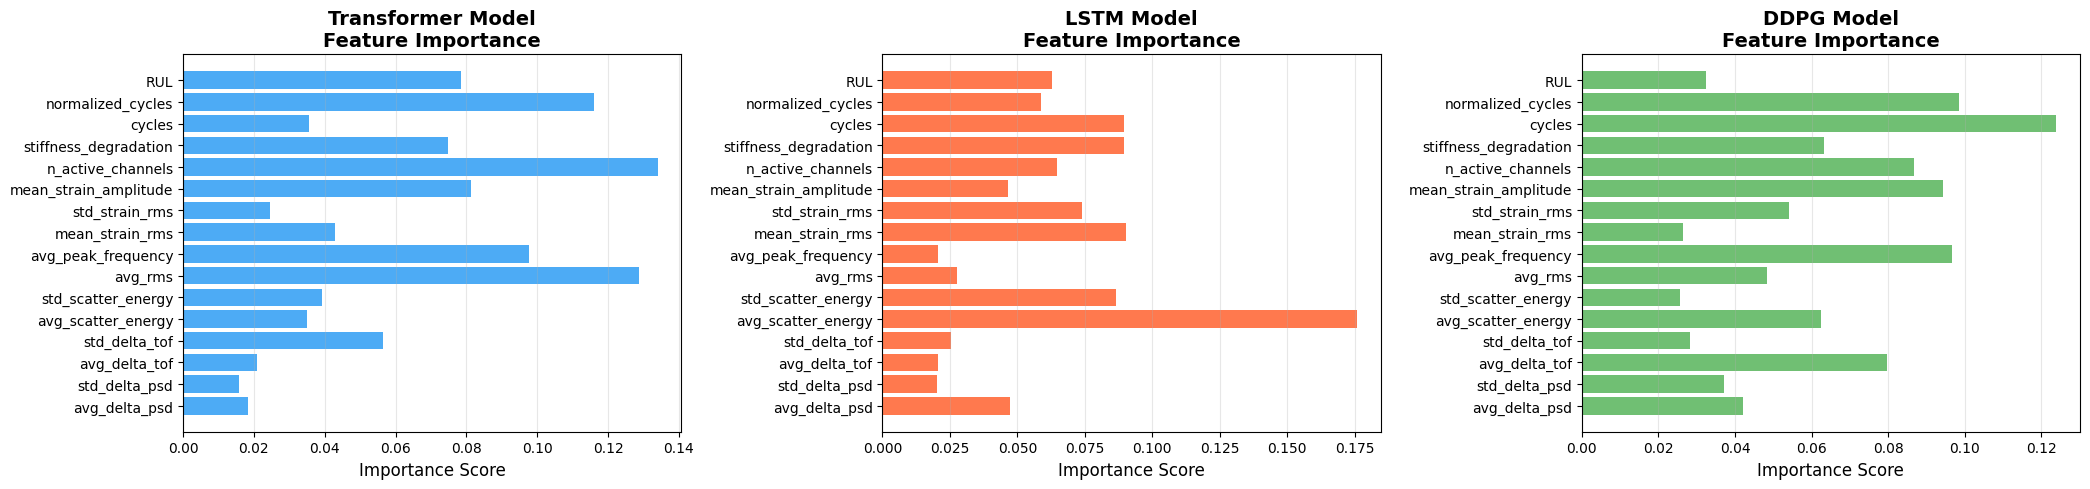


Feature Importance Comparison:
Feature              Transformer     LSTM            DDPG           
avg_delta_psd        0.0183          0.0471          0.0421         
std_delta_psd        0.0159          0.0203          0.0371         
avg_delta_tof        0.0209          0.0207          0.0798         
std_delta_tof        0.0565          0.0253          0.0282         
avg_scatter_energy   0.0349          0.1758          0.0626         
std_scatter_energy   0.0393          0.0864          0.0255         
avg_rms              0.1287          0.0277          0.0484         
avg_peak_frequency   0.0976          0.0208          0.0965         
mean_strain_rms      0.0429          0.0902          0.0264         
std_strain_rms       0.0247          0.0740          0.0542         
mean_strain_amplitude 0.0814          0.0464          0.0943         
n_active_channels    0.1340          0.0648          0.0868         
stiffness_degradation 0.0749          0.0896          0.0633         


In [32]:
# Compare feature importance across models
num_models = 3
fig, axes = plt.subplots(1, num_models, figsize=(7*num_models, 5))

if num_models == 2:
    axes = [axes[0], axes[1]]

# Transformer
features = list(transformer_exp['feature_importance'].keys())
importances_t = [transformer_exp['feature_importance'][f] for f in features]
axes[0].barh(features, importances_t, color='#2196F3', alpha=0.8)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Transformer Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# LSTM
importances_l = [lstm_exp['feature_importance'][f] for f in features]
axes[1].barh(features, importances_l, color='#FF5722', alpha=0.8)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('LSTM Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)


importances_d = [ddpg_exp['feature_importance'][f] for f in features]
axes[2].barh(features, importances_d, color='#4CAF50', alpha=0.8)
axes[2].set_xlabel('Importance Score', fontsize=12)
axes[2].set_title('DDPG Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
print("\nFeature Importance Comparison:")
print(f"{'Feature':<20} {'Transformer':<15} {'LSTM':<15} {'DDPG':<15}")
print("="*80)
for feature in features:
    t_imp = transformer_exp['feature_importance'][feature]
    l_imp = lstm_exp['feature_importance'][feature]
    d_imp = ddpg_exp['feature_importance'][feature]
    print(f"{feature:<20} {t_imp:<15.4f} {l_imp:<15.4f} {d_imp:<15.4f}")

## 8. Interactive Sample Explorer

Create an interactive widget to explore explanations for different samples.

In [33]:
from ipywidgets import interact, IntSlider, Dropdown

def explore_sample(sample_idx, model_choice):
    """Interactive function to explore different samples"""
    
    # Get sample and actual RUL
    sample_sequence = X_test[sample_idx:sample_idx+1]  # Keep batch dimension
    actual_rul_normalized = float(y_test[sample_idx])
    actual_rul = target_scaler.inverse_transform([[actual_rul_normalized]])[0, 0]
    
    # Select model, explainer and color
    if model_choice == 'Transformer':
        model = transformer_model
        explainer = transformer_explainer
        color = '#2196F3'
    elif model_choice == 'LSTM':
        model = lstm_model
        explainer = lstm_explainer
        color = '#FF5722'
    elif model_choice == 'DDPG':
        model = ddpg_model
        explainer = ddpg_explainer
        color = '#4CAF50'
    else:
        print(f"Model {model_choice} not available")
        return
    
    # Generate explanation using new API with target_scaler
    exp = explainer.explain_prediction(
        model=model,
        sample=sample_sequence,
        feature_names=feature_names,
        model_type=model_choice.lower(),
        top_k=10,
        target_scaler=target_scaler  # Required!
    )
    exp['actual_rul'] = actual_rul
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Feature importance
    features = list(exp['feature_importance'].keys())
    importances = [exp['feature_importance'][f] for f in features]
    axes[0].barh(features, importances, color=color, alpha=0.8)
    axes[0].set_xlabel('Importance Score (Normalized)', fontsize=12)
    axes[0].set_title(f'{model_choice} - Feature Importance', fontsize=13, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Prediction info
    axes[1].axis('off')
    
    # Calculate error and error percentage
    error = abs(exp['predicted_rul'] - actual_rul)
    error_percent = (error / max(actual_rul, 1)) * 100
    
    info_text = f"""
    MODEL: {model_choice}
    
    PREDICTION:
    • Predicted RUL: {exp['predicted_rul']:.0f} cycles
      (normalized: {exp['predicted_rul_normalized']:.4f})
    • Actual RUL: {actual_rul:.0f} cycles
      (normalized: {actual_rul_normalized:.4f})
    • Error: {error:.0f} cycles ({error_percent:.1f}%)
    
    TOP 3 FEATURES:
    """
    for i, (feat, imp) in enumerate(exp['feature_importances'][:3], 1):
        info_text += f"\n    {i}. {feat}: {imp:.6f} ({imp*100:.2f}%)"
    
    info_text += "\n\n    KG EXPLANATION PATHS:\n"
    if exp['paths']:
        for i, path in enumerate(exp['paths'][:2], 1):
            path_str = " → ".join([node['name'] for node in path['nodes']])
            info_text += f"\n    {i}. {path_str}\n       (strength: {path['strength']:.3f})\n"
    else:
        info_text += "\n    (No paths found)"
    
    axes[1].text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()

# Create interactive widget with DDPG option
model_options = ['Transformer', 'LSTM', 'DDPG']

interact(
    explore_sample,
    sample_idx=IntSlider(min=0, max=len(X_test)-1, value=10, description='Sample:'),
    model_choice=Dropdown(options=model_options, value='DDPG', description='Model:')
);

interactive(children=(IntSlider(value=10, description='Sample:', max=29), Dropdown(description='Model:', index…